In [165]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
import pickle
import matplotlib as mpl
import seaborn as sb
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [166]:
import json

path = "info\\non_cnn_analysis.json"
with open(path, 'r') as f:
    results = json.load(f)

path = "info\\cnn_analysis_results.json"
with open(path, 'r') as f:
    cnn_results = json.load(f)


# Part 1: Orth Data

### Compare mlp and linear orth

In [167]:
mlp_orth = results['mlp\\orth']
linear_orth = results['linear\\orth']
cnn_orth = cnn_results['cnn\\orth']

First, determine optimal hyperparameters, firstly for the 128-64 model

In [168]:
model_regular.keys()

dict_keys(['datapath', 'batch size', 'hidden size', 'split vector', 'filter channels', 'filter sizes', 'mag cost', 'model type', 'min val loss', 'final val loss', ' train loss', 'final train loss', 'exp1 evaluation stats', 'exp2 evaluation stats', 'exp3 evaluation stats', 'exp4 evaluation stats', 'convergence', 'convergence std', 'convergence_stats', 'convergence after iterations', 'convergence after iterations std', 'convergence stats after iterations', 'num convergence iterations', 'optimal scalings', 'exp scaling stats'])

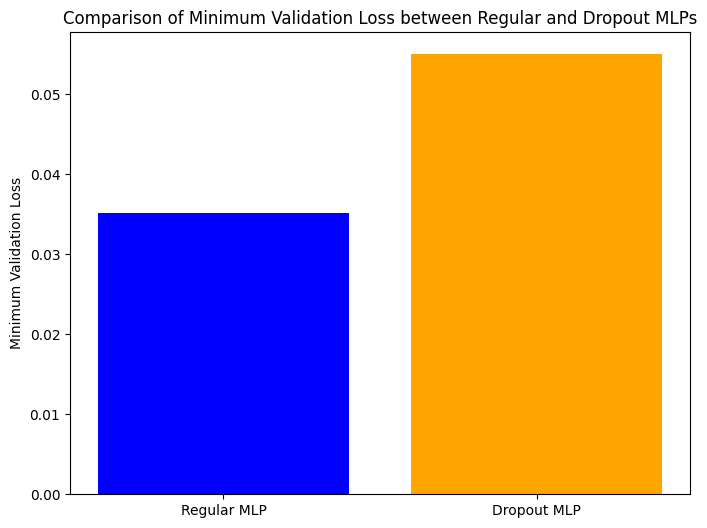

In [169]:
options = ['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1']

model_regular = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
model_dropout = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1']

regular_min_val_loss = model_regular['min val loss']
dropout_min_val_loss = model_dropout['min val loss']

plt.figure(figsize=(8,6))
plt.bar(['Regular MLP', 'Dropout MLP'], [regular_min_val_loss, dropout_min_val_loss], color=['blue', 'orange'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss between Regular and Dropout MLPs')
plt.show()

Ok lets compare all the main models.

In [170]:
mlp_orth.keys()

dict_keys(['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images'])

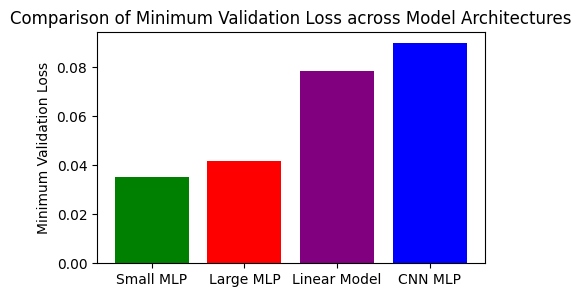

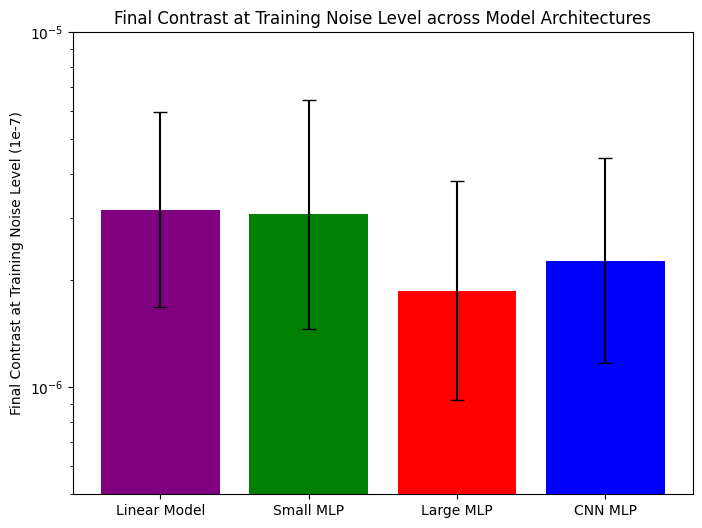

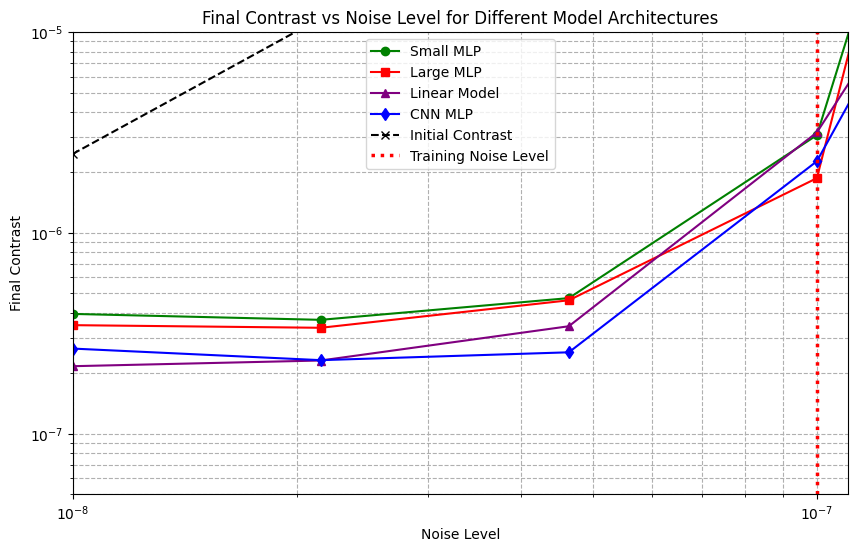

In [171]:
small_mlp_regular = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
large_mlp_regular = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images']
cnn_mlp_regular = cnn_orth['exp-fc1-zscore-ep1000-bs2048-lr1e-3-s42-h128-64-images']
linear_regular = linear_orth['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images']

plt.figure(figsize=(5,3))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', "CNN MLP"],
        [small_mlp_regular['min val loss'], large_mlp_regular['min val loss'], linear_regular['min val loss'], cnn_mlp_regular['min val loss']],
        color=['green', 'red', 'purple', 'blue'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss across Model Architectures')
plt.show()

smr_exp1 = small_mlp_regular['exp1 evaluation stats']
lmr_exp1 = large_mlp_regular['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnnr_exp1_final_contrast_log_mean = np.array(cnnr_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnnr_exp1_final_contrast = 10 ** cnnr_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnnr_exp1_final_contrast_log_std = np.array(cnnr_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']

train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]


def log_std_to_linear_error(log_mean, log_std):
    base = 10 ** log_mean
    lower_err = base - 10 ** (log_mean - log_std)
    upper_err = 10 ** (log_mean + log_std) - base
    return np.array([lower_err, upper_err])


model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnnr_exp1_final_contrast_log_mean[noise_level_index], cnnr_exp1_final_contrast_log_std[noise_level_index])
]

yerr = np.array(model_error_bars).T

plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN MLP'],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnnr_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'blue'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
plt.xlim(1e-8, 1.1e-7)
plt.ylim(5e-8, 1e-5)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

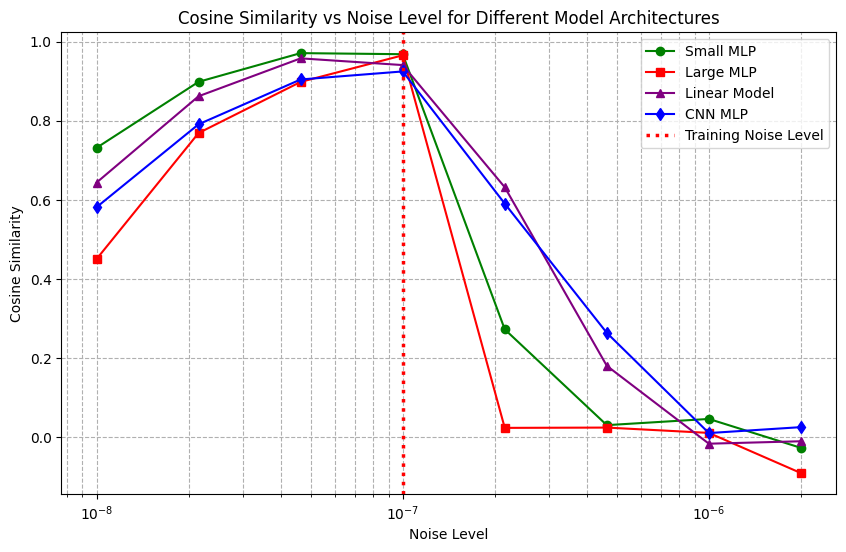

In [172]:
smr_exp1 = small_mlp_regular['exp1 evaluation stats']
lmr_exp1 = large_mlp_regular['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']

smr_exp1_cos_sim = np.array(smr_exp1['cosine_similarity']['mean'])
lmr_exp1_cos_sim = np.array(lmr_exp1['cosine_similarity']['mean'])
lr_exp1_cos_sim = np.array(lr_exp1['cosine_similarity']['mean'])
cnnr_exp1_cos_sim = np.array(cnnr_exp1['cosine_similarity']['mean'])


plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(0, 1)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

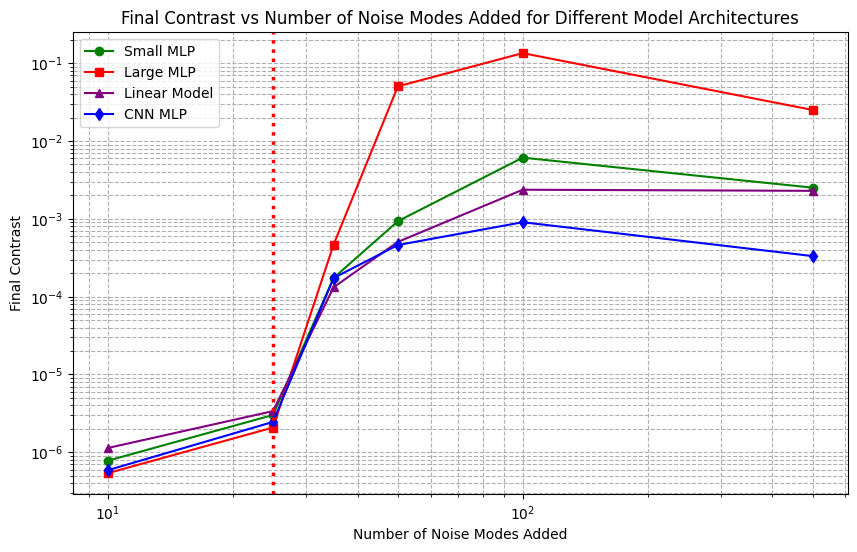

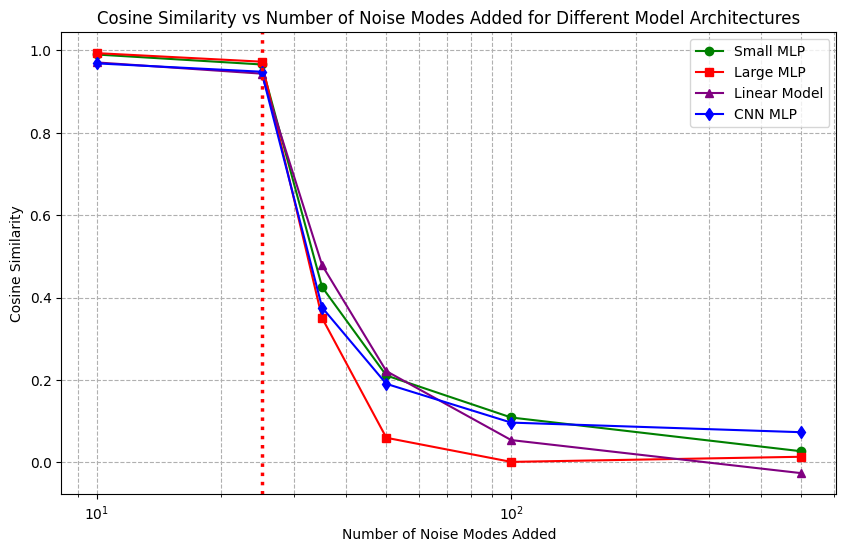

In [173]:
smr_exp2 = small_mlp_regular['exp2 evaluation stats']
lmr_exp2 = large_mlp_regular['exp2 evaluation stats']
lr_exp2 = linear_regular['exp2 evaluation stats']
cnnr_exp2 = cnn_mlp_regular['exp2 evaluation stats']

noise_mode_amounts = smr_exp2['noise_mode_amounts']

smr_exp2_final_contrast_log_mean = np.array(smr_exp2['final_contrast_log10']['mean'])
lmr_exp2_final_contrast_log_mean = np.array(lmr_exp2['final_contrast_log10']['mean'])
lr_exp2_final_contrast_log_mean = np.array(lr_exp2['final_contrast_log10']['mean'])
cnnr_exp2_final_contrast_log_mean = np.array(cnnr_exp2['final_contrast_log10']['mean'])
smr_exp2_final_contrast = 10 ** smr_exp2_final_contrast_log_mean
lmr_exp2_final_contrast = 10 ** lmr_exp2_final_contrast_log_mean
lr_exp2_final_contrast = 10 ** lr_exp2_final_contrast_log_mean 
cnnr_exp2_final_contrast = 10 ** cnnr_exp2_final_contrast_log_mean

smr_exp2_cos_sim = np.array(smr_exp2['cosine_similarity']['mean'])
lmr_exp2_cos_sim = np.array(lmr_exp2['cosine_similarity']['mean'])
lr_exp2_cos_sim = np.array(lr_exp2['cosine_similarity']['mean'])
cnnr_exp2_cos_sim = np.array(cnnr_exp2['cosine_similarity']['mean'])


plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnnr_exp2_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnnr_exp2_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()


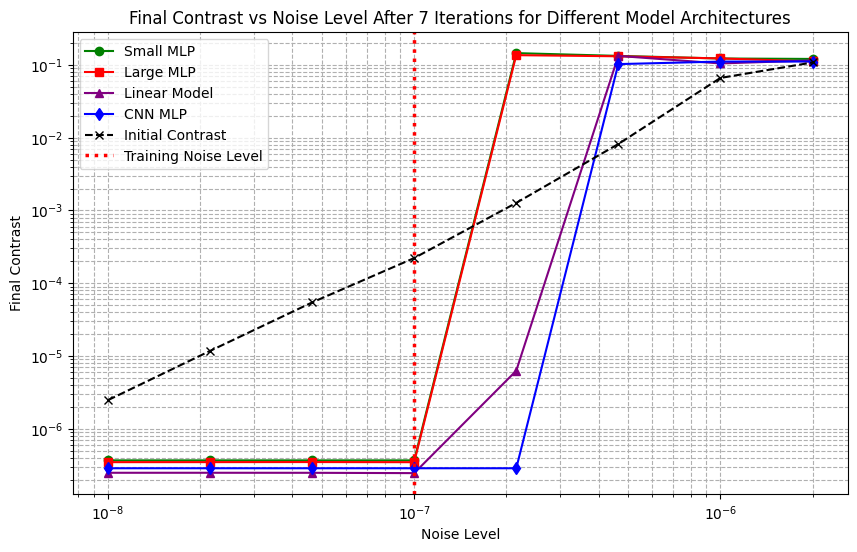

In [174]:
smr_exp3 = small_mlp_regular['exp3 evaluation stats']
lmr_exp3 = large_mlp_regular['exp3 evaluation stats']
lr_exp3 = linear_regular['exp3 evaluation stats']
cnnr_exp3 = cnn_mlp_regular['exp3 evaluation stats']

noise_levels_exp3 = smr_exp3['noise_levels']
smr_exp3_final_contrast_log_mean = np.array(smr_exp3['final_contrast_log10']['mean'])
lmr_exp3_final_contrast_log_mean = np.array(lmr_exp3['final_contrast_log10']['mean'])
lr_exp3_final_contrast_log_mean = np.array(lr_exp3['final_contrast_log10']['mean'])
cnnr_exp3_final_contrast_log_mean = np.array(cnnr_exp3['final_contrast_log10']['mean'])
smr_exp3_final_contrast = 10 ** smr_exp3_final_contrast_log_mean
lmr_exp3_final_contrast = 10 ** lmr_exp3_final_contrast_log_mean
lr_exp3_final_contrast = 10 ** lr_exp3_final_contrast_log_mean
cnnr_exp3_final_contrast = 10 ** cnnr_exp3_final_contrast_log_mean

plt.figure(figsize=(10,6))
plt.plot(noise_levels_exp3, smr_exp3_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels_exp3, lmr_exp3_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels_exp3, lr_exp3_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels_exp3, cnnr_exp3_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels_exp3, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level After 7 Iterations for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Now, let's add the random model training for MLPs

In [175]:
mlp_orth_rand = results['mlp\\orth rand']
mlp_orth_rand.keys()

dict_keys(['exp-fc1-log-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.1'])

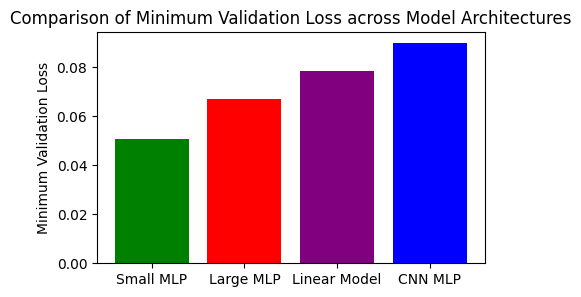

In [176]:
small_mlp_rand = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
large_mlp_rand = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images']

plt.figure(figsize=(5,3))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', "CNN MLP"],
        [small_mlp_rand['min val loss'], large_mlp_rand['min val loss'], linear_regular['min val loss'], cnn_mlp_regular['min val loss']],
        color=['green', 'red', 'purple', 'blue'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss across Model Architectures')
plt.show()


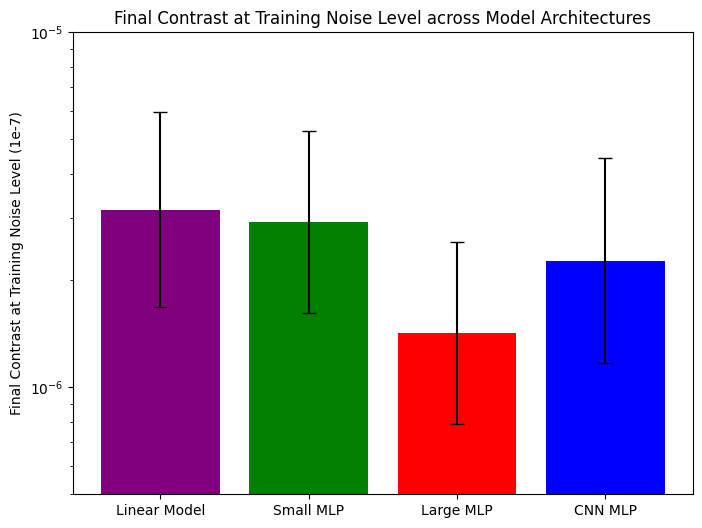

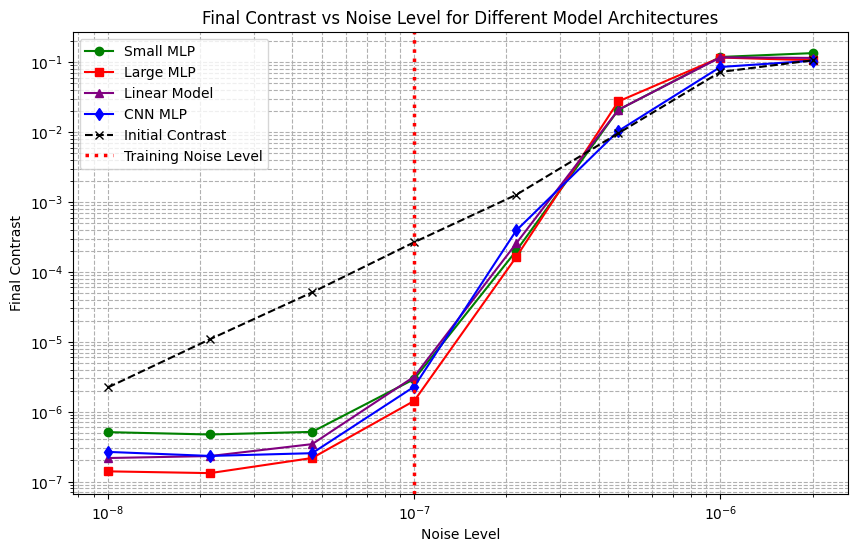

In [177]:
smr_exp1 = small_mlp_rand['exp1 evaluation stats']
lmr_exp1 = large_mlp_rand['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnnr_exp1_final_contrast_log_mean = np.array(cnnr_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnnr_exp1_final_contrast = 10 ** cnnr_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnnr_exp1_final_contrast_log_std = np.array(cnnr_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']

train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]


def log_std_to_linear_error(log_mean, log_std):
    base = 10 ** log_mean
    lower_err = base - 10 ** (log_mean - log_std)
    upper_err = 10 ** (log_mean + log_std) - base
    return np.array([lower_err, upper_err])


model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnnr_exp1_final_contrast_log_mean[noise_level_index], cnnr_exp1_final_contrast_log_std[noise_level_index])
]

yerr = np.array(model_error_bars).T

plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN MLP'],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnnr_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'blue'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(5e-8, 1e-5)

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

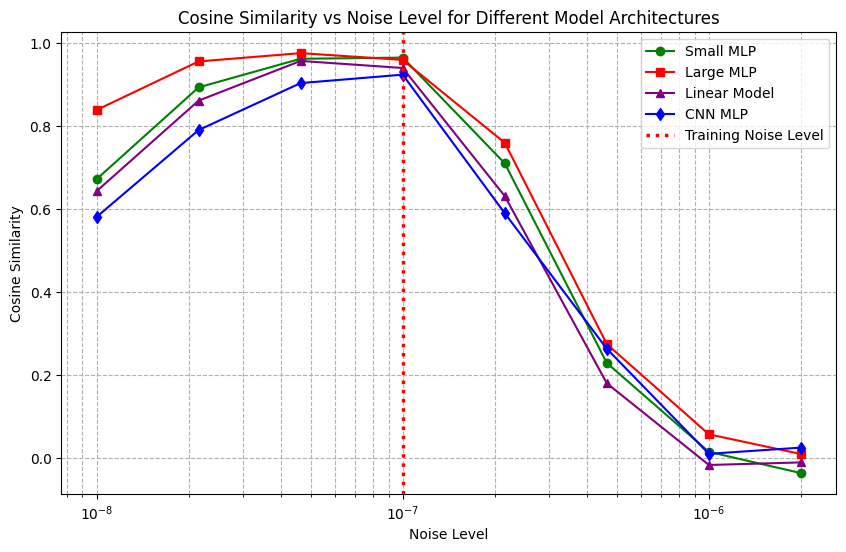

In [178]:
smr_exp1 = small_mlp_rand['exp1 evaluation stats']
lmr_exp1 = large_mlp_rand['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']

smr_exp1_cos_sim = np.array(smr_exp1['cosine_similarity']['mean'])
lmr_exp1_cos_sim = np.array(lmr_exp1['cosine_similarity']['mean'])
lr_exp1_cos_sim = np.array(lr_exp1['cosine_similarity']['mean'])
cnnr_exp1_cos_sim = np.array(cnnr_exp1['cosine_similarity']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(0, 1)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

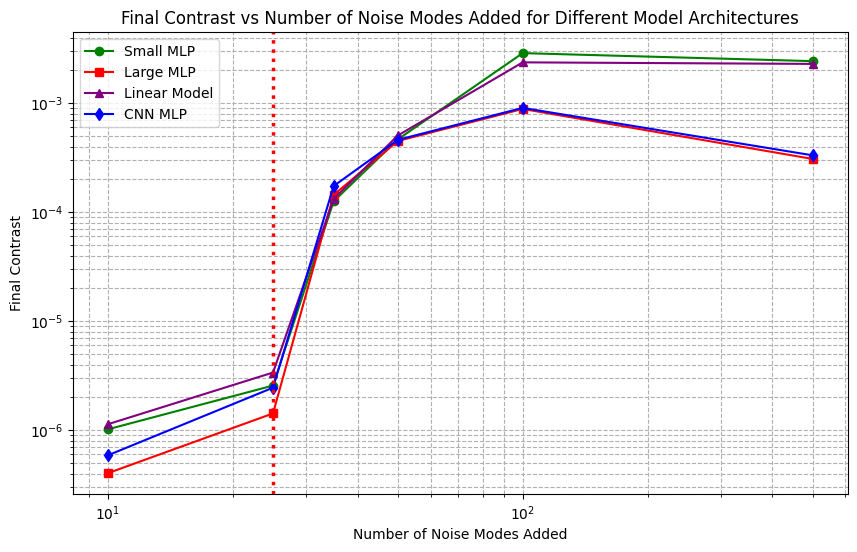

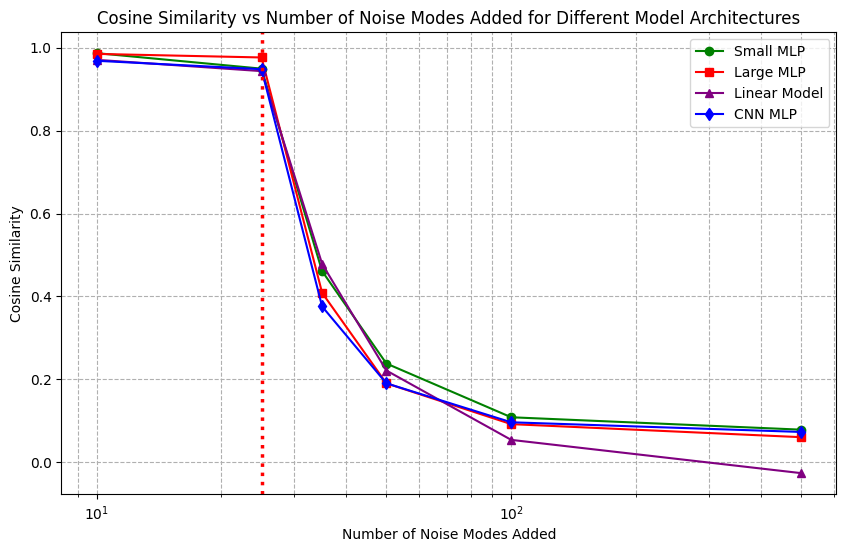

In [179]:
smr_exp2 = small_mlp_rand['exp2 evaluation stats']
lmr_exp2 = large_mlp_rand['exp2 evaluation stats']
lr_exp2 = linear_regular['exp2 evaluation stats']
cnnr_exp2 = cnn_mlp_regular['exp2 evaluation stats']

noise_mode_amounts = smr_exp2['noise_mode_amounts']

smr_exp2_final_contrast_log_mean = np.array(smr_exp2['final_contrast_log10']['mean'])
lmr_exp2_final_contrast_log_mean = np.array(lmr_exp2['final_contrast_log10']['mean'])
lr_exp2_final_contrast_log_mean = np.array(lr_exp2['final_contrast_log10']['mean'])
cnnr_exp2_final_contrast_log_mean = np.array(cnnr_exp2['final_contrast_log10']['mean'])
smr_exp2_final_contrast = 10 ** smr_exp2_final_contrast_log_mean
lmr_exp2_final_contrast = 10 ** lmr_exp2_final_contrast_log_mean
lr_exp2_final_contrast = 10 ** lr_exp2_final_contrast_log_mean 
cnnr_exp2_final_contrast = 10 ** cnnr_exp2_final_contrast_log_mean

smr_exp2_cos_sim = np.array(smr_exp2['cosine_similarity']['mean'])
lmr_exp2_cos_sim = np.array(lmr_exp2['cosine_similarity']['mean'])
lr_exp2_cos_sim = np.array(lr_exp2['cosine_similarity']['mean'])
cnnr_exp2_cos_sim = np.array(cnnr_exp2['cosine_similarity']['mean'])


plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnnr_exp2_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnnr_exp2_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()


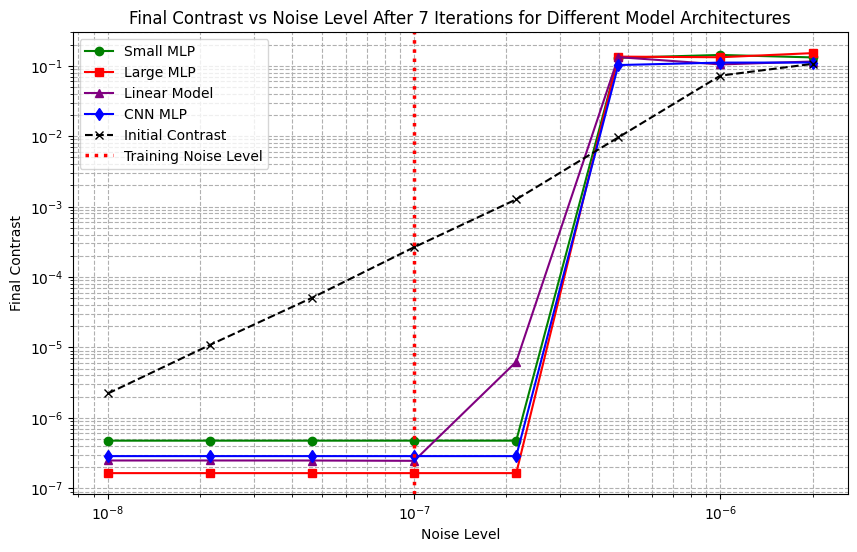

In [180]:
smr_exp3 = small_mlp_rand['exp3 evaluation stats']
lmr_exp3 = large_mlp_rand['exp3 evaluation stats']
lr_exp3 = linear_regular['exp3 evaluation stats']
cnnr_exp3 = cnn_mlp_regular['exp3 evaluation stats']

noise_levels_exp3 = smr_exp3['noise_levels']
smr_exp3_final_contrast_log_mean = np.array(smr_exp3['final_contrast_log10']['mean'])
lmr_exp3_final_contrast_log_mean = np.array(lmr_exp3['final_contrast_log10']['mean'])
lr_exp3_final_contrast_log_mean = np.array(lr_exp3['final_contrast_log10']['mean'])
cnnr_exp3_final_contrast_log_mean = np.array(cnnr_exp3['final_contrast_log10']['mean'])
smr_exp3_final_contrast = 10 ** smr_exp3_final_contrast_log_mean
lmr_exp3_final_contrast = 10 ** lmr_exp3_final_contrast_log_mean
lr_exp3_final_contrast = 10 ** lr_exp3_final_contrast_log_mean
cnnr_exp3_final_contrast = 10 ** cnnr_exp3_final_contrast_log_mean

plt.figure(figsize=(10,6))
plt.plot(noise_levels_exp3, smr_exp3_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels_exp3, lmr_exp3_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels_exp3, lr_exp3_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels_exp3, cnnr_exp3_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels_exp3, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level After 7 Iterations for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

C:\Users\alexe\AppData\Local\Temp\ipykernel_39280\3068769848.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


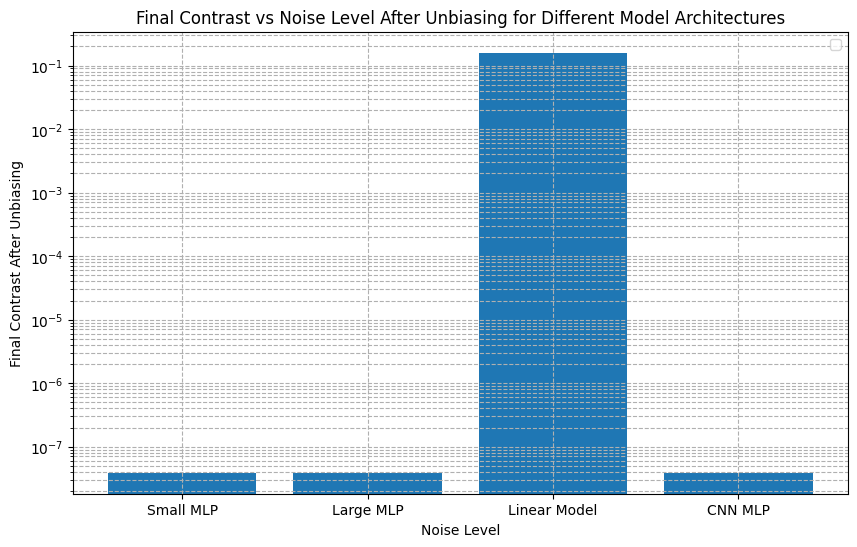

C:\Users\alexe\AppData\Local\Temp\ipykernel_39280\3068769848.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


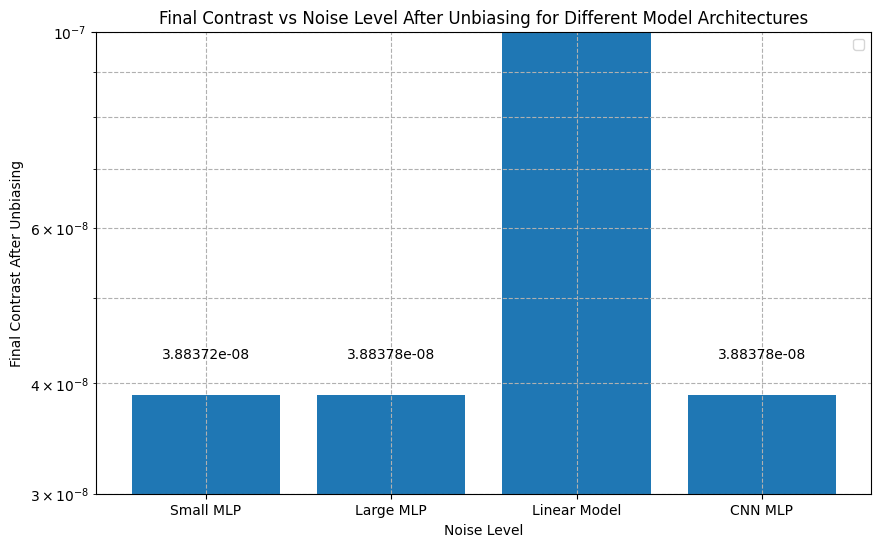

In [181]:
smr_conv = small_mlp_rand['convergence stats after iterations']
lmr_conv = large_mlp_rand['convergence stats after iterations']
lr_conv = linear_regular['convergence stats after iterations']
cnnr_conv = cnn_mlp_regular['convergence stats after iterations']

smr_conv_final_contrast_log_mean = np.array(smr_conv['final_contrast_log10']['mean'])
lmr_conv_final_contrast_log_mean = np.array(lmr_conv['final_contrast_log10']['mean'])
lr_conv_final_contrast_log_mean = np.array(lr_conv['final_contrast_log10']['mean'])
cnnr_conv_final_contrast_log_mean = np.array(cnnr_conv['final_contrast_log10']['mean'])
smr_conv_final_contrast = 10 ** smr_conv_final_contrast_log_mean
lmr_conv_final_contrast = 10 ** lmr_conv_final_contrast_log_mean
lr_conv_final_contrast = 10 ** lr_conv_final_contrast_log_mean
cnnr_conv_final_contrast = 10 ** cnnr_conv_final_contrast_log_mean

plt.figure(figsize=(10,6))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', 'CNN MLP'],
        [smr_conv_final_contrast[0], lmr_conv_final_contrast[0], lr_conv_final_contrast[0], cnnr_conv_final_contrast[0]])
# plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
# plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast After Unbiasing')
plt.title('Final Contrast vs Noise Level After Unbiasing for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', 'CNN MLP'],
        [smr_conv_final_contrast[0], lmr_conv_final_contrast[0], lr_conv_final_contrast[0], cnnr_conv_final_contrast[0]])
# plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
# plt.xscale('log')
plt.text(0, smr_conv_final_contrast[0]*1.1, f"{smr_conv_final_contrast[0]:.5e}", ha='center')
plt.text(1, lmr_conv_final_contrast[0]*1.1, f"{lmr_conv_final_contrast[0]:.5e}", ha='center')
plt.text(3, cnnr_conv_final_contrast[0]*1.1, f"{cnnr_conv_final_contrast[0]:.5e}", ha='center')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast After Unbiasing')
plt.title('Final Contrast vs Noise Level After Unbiasing for Different Model Architectures')
plt.legend()
plt.ylim(3e-8, 1e-7)
plt.grid(True, which="both", ls="--")
plt.show()

Debiasing did not quite work on the linear model, but on all the other models it looks like they reach a certain plateau.

In [182]:
mlp_orth.keys()

dict_keys(['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images'])

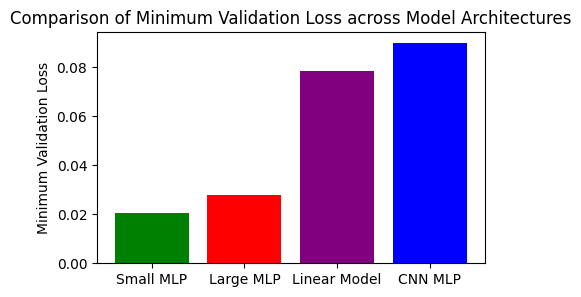

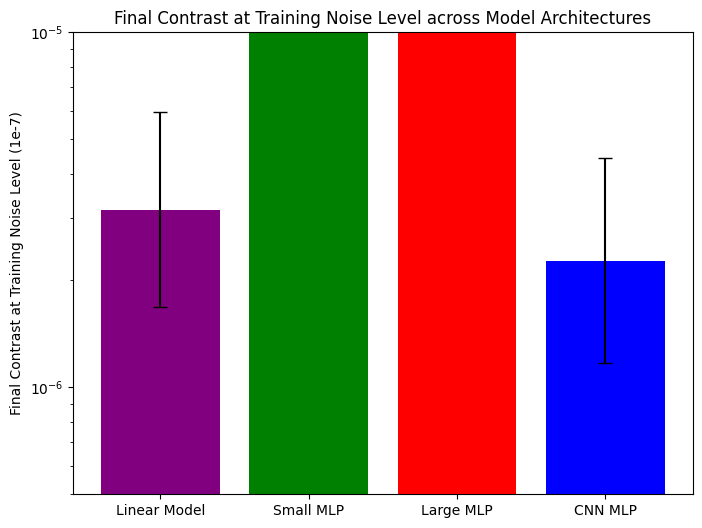

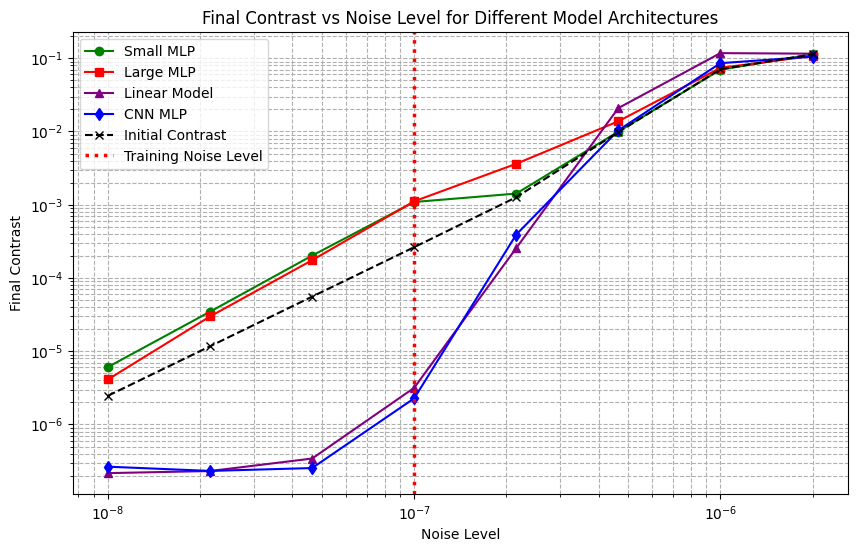

In [183]:
smr_split = mlp_orth['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0']
lmr_split = mlp_orth['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0']

plt.figure(figsize=(5,3))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', "CNN MLP"],
        [smr_split['min val loss'], lmr_split['min val loss'], linear_regular['min val loss'], cnn_mlp_regular['min val loss']],
        color=['green', 'red', 'purple', 'blue'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss across Model Architectures')
plt.show()

smr_exp1 = smr_split['exp scaling stats']
lmr_exp1 = lmr_split['exp scaling stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']
smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnnr_exp1_final_contrast_log_mean = np.array(cnnr_exp1['final_contrast_log10']['mean'])
smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnnr_exp1_final_contrast = 10 ** cnnr_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnnr_exp1_final_contrast_log_std = np.array(cnnr_exp1['final_contrast_log10']['std'])
initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']
train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnnr_exp1_final_contrast_log_mean[noise_level_index], cnnr_exp1_final_contrast_log_std[noise_level_index])
]
yerr = np.array(model_error_bars).T
plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN MLP'],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnnr_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'blue'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

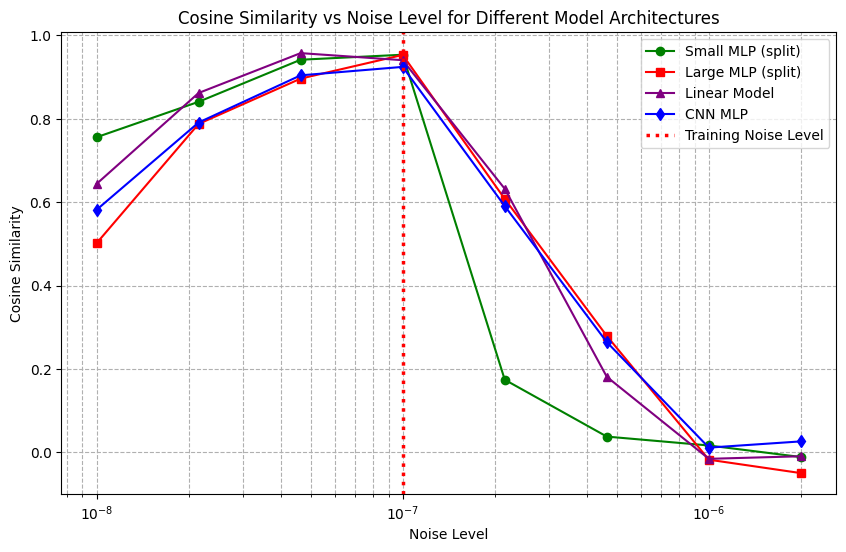

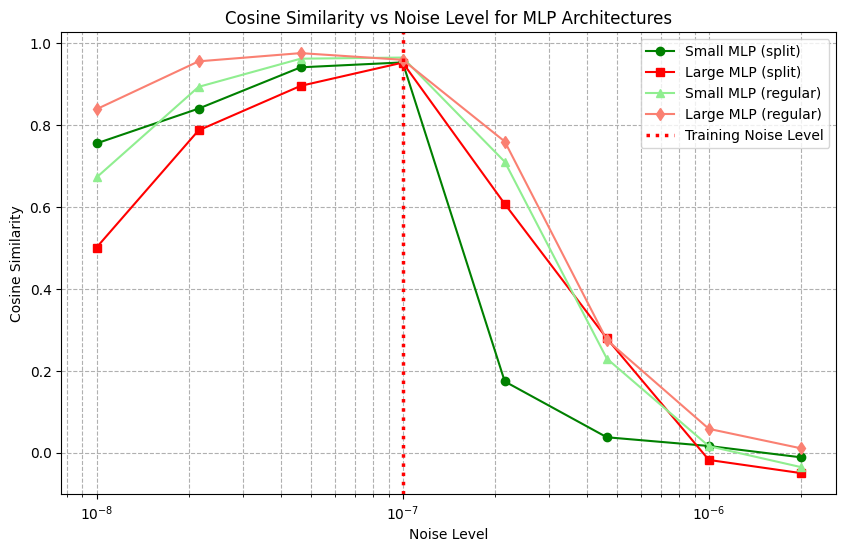

In [184]:
smr_split_cos_sim = np.array(smr_exp1['cosine_similarity']['mean'])
lmr_split_cos_sim = np.array(lmr_exp1['cosine_similarity']['mean'])
lr_exp1_cos_sim = np.array(lr_exp1['cosine_similarity']['mean'])
cnnr_exp1_cos_sim = np.array(cnnr_exp1['cosine_similarity']['mean'])
plt.figure(figsize=(10,6))
plt.plot(noise_levels, -smr_split_cos_sim, marker='o', label='Small MLP (split)', color='green')
plt.plot(noise_levels, -lmr_split_cos_sim, marker='s', label='Large MLP (split)', color='red')
plt.plot(noise_levels, lr_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, -smr_split_cos_sim, marker='o', label='Small MLP (split)', color='green')
plt.plot(noise_levels, -lmr_split_cos_sim, marker='s', label='Large MLP (split)', color='red')
plt.plot(noise_levels, smr_exp1_cos_sim, marker='^', label='Small MLP (regular)', color='lightgreen')
plt.plot(noise_levels, lmr_exp1_cos_sim, marker='d', label='Large MLP (regular)', color='salmon')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for MLP Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Optimizing for COS similarity directly doesn't seem to be too good of an idea.

In [185]:
mlp_orth_rand.keys()

dict_keys(['exp-fc1-log-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.1'])

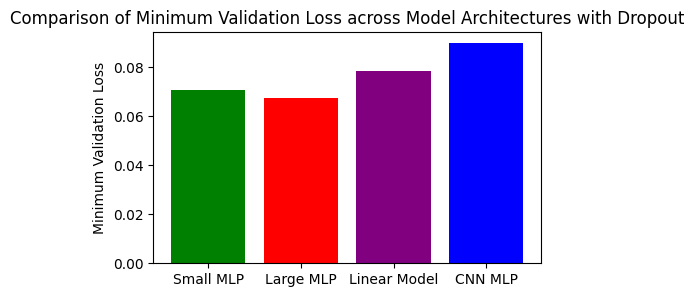

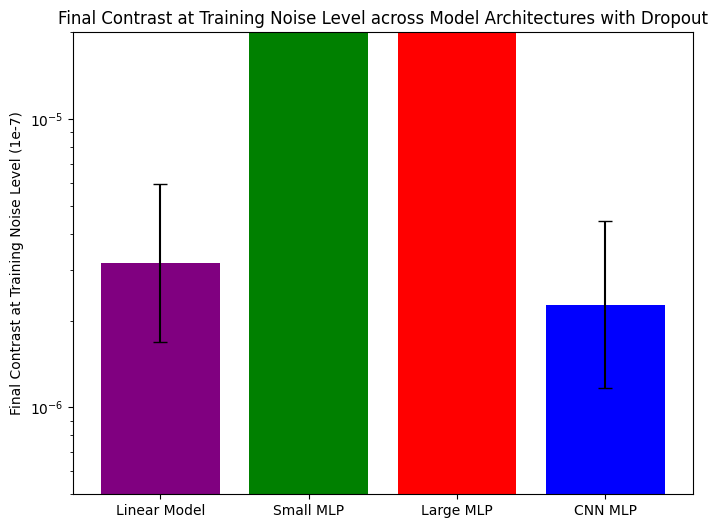

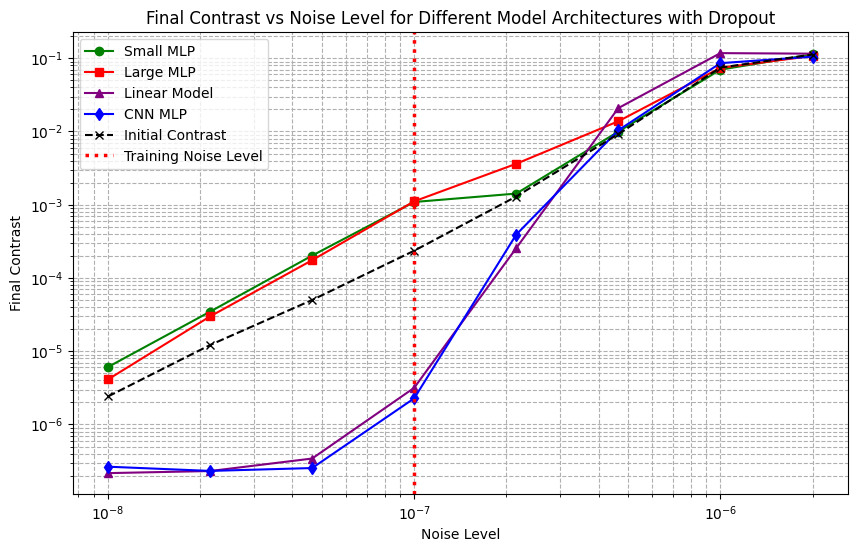

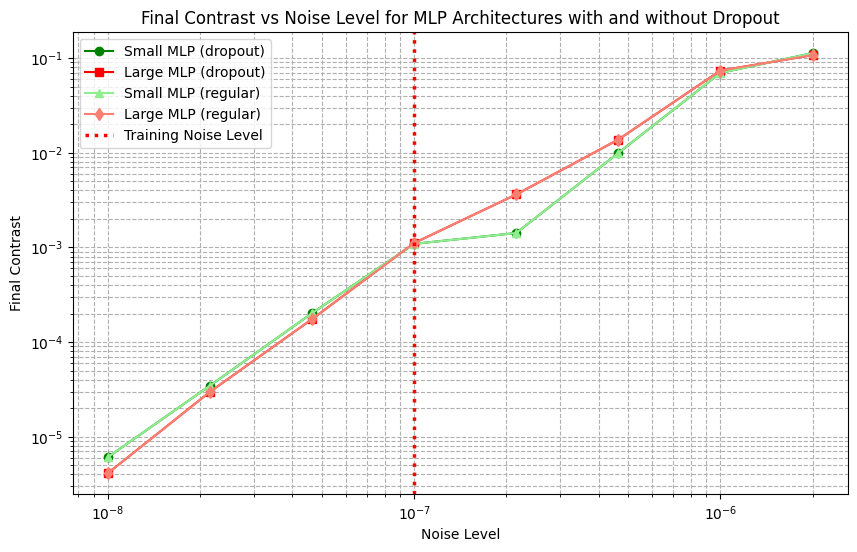

In [186]:
smr_rand_drop = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1']
lmr_rand_drop = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.1']

plt.figure(figsize=(5,3))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', "CNN MLP"],
        [smr_rand_drop['min val loss'], lmr_rand_drop['min val loss'], linear_regular['min val loss'], cnn_mlp_regular['min val loss']],
        color=['green', 'red', 'purple', 'blue'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss across Model Architectures with Dropout')
plt.show()

smr_exp1 = smr_rand_drop['exp1 evaluation stats']
lmr_exp1 = lmr_rand_drop['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']
smr_exp1_final_contrast_log_drop_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_drop_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnnr_exp1_final_contrast_log_mean = np.array(cnnr_exp1['final_contrast_log10']['mean'])
smr_exp1_final_contrast_drop = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast_drop = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnnr_exp1_final_contrast = 10 ** cnnr_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std_drop = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std_drop = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnnr_exp1_final_contrast_log_std = np.array(cnnr_exp1['final_contrast_log10']['std'])
initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']
train_noise_level = 1e-7
noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_drop_mean[noise_level_index], smr_exp1_final_contrast_log_std_drop[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std_drop[noise_level_index]),
    log_std_to_linear_error(cnnr_exp1_final_contrast_log_mean[noise_level_index], cnnr_exp1_final_contrast_log_std[noise_level_index])
]

yerr = np.array(model_error_bars).T

plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN MLP'],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast_drop[noise_level_index], lmr_exp1_final_contrast_drop[noise_level_index], cnnr_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'blue'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures with Dropout')
plt.yscale('log')
plt.ylim(5e-7, 2e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast_drop, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast_drop, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures with Dropout')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast_drop, marker='o', label='Small MLP (dropout)', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast_drop, marker='s', label='Large MLP (dropout)', color='red')
plt.plot(noise_levels, smr_exp1_final_contrast, marker='^', label='Small MLP (regular)', color='lightgreen')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='d', label='Large MLP (regular)', color='salmon')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for MLP Architectures with and without Dropout')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [197]:
mlp_LA = results['mlp\\LA']
linear_LA = results['linear\\LA']
cnn_LA = cnn_results['cnn\\LA']

In [194]:
cnn_LA.keys()

dict_keys(['exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h128-64-images-wd0.0005-do0.1', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h256-128-images', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h256-128-images-wd0.001-do0.2', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h64-32-images', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h64-32-images-wd0.0005-do0.1', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h64-images', 'exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h64-images-wd0.0005-do0.1'])

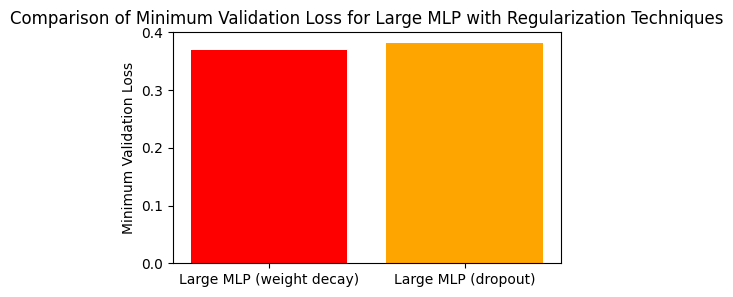

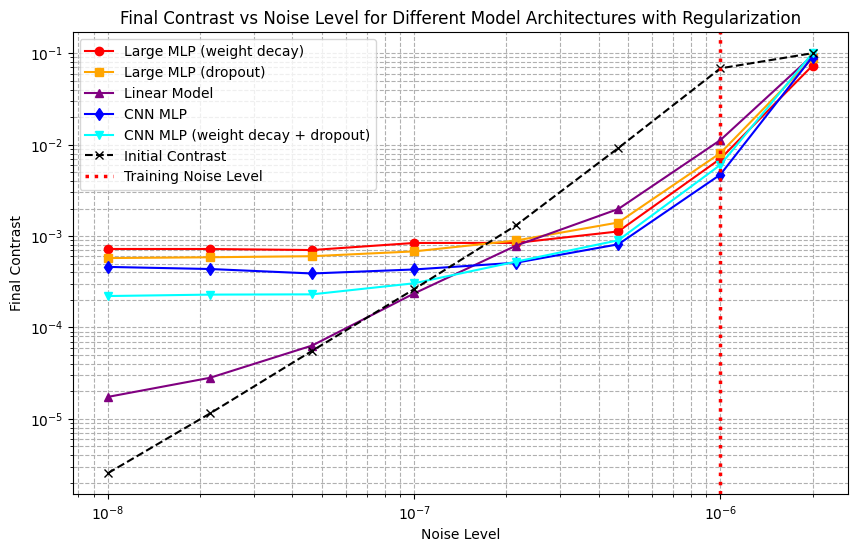

In [204]:
large_mlp_LA_wd = mlp_LA['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005']
large_mlp_LA_drop = mlp_LA['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.2']
lm_LA = linear_LA['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images']
cnnr_LA = cnn_LA['exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h128-64-images']
cnnr_LA_wd_drop = cnn_LA['exp-fc1-zscore-ep2000-bs2048-lr1e-3-s42-h128-64-images-wd0.0005-do0.1']

plt.figure(figsize=(5,3))
plt.bar(['Large MLP (weight decay)', 'Large MLP (dropout)'],
        [large_mlp_LA_wd['min val loss'], large_mlp_LA_drop['min val loss']],
        color=['red', 'orange'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss for Large MLP with Regularization Techniques')
plt.show()

large_mlp_LA_wd_exp1 = large_mlp_LA_wd['exp1 evaluation stats']
large_mlp_LA_drop_exp1 = large_mlp_LA_drop['exp1 evaluation stats']
lm_LA_exp1 = lm_LA['exp1 evaluation stats']
cnnr_LA_exp1 = cnnr_LA['exp1 evaluation stats']
cnnr_LA_wd_drop_exp1 = cnnr_LA_wd_drop['exp1 evaluation stats']
large_mlp_LA_wd_exp1_final_contrast_log_mean = np.array(large_mlp_LA_wd_exp1['final_contrast_log10']['mean'])
large_mlp_LA_drop_exp1_final_contrast_log_mean = np.array(large_mlp_LA_drop_exp1['final_contrast_log10']['mean'])
lm_LA_exp1_final_contrast_log_mean = np.array(lm_LA_exp1['final_contrast_log10']['mean'])
cnnr_LA_exp1_final_contrast_log_mean = np.array(cnnr_LA_exp1['final_contrast_log10']['mean'])
cnnr_LA_wd_drop_exp1_final_contrast_log_mean = np.array(cnnr_LA_wd_drop_exp1['final_contrast_log10']['mean'])
large_mlp_LA_wd_exp1_final_contrast = 10 ** large_mlp_LA_wd_exp1_final_contrast_log_mean
large_mlp_LA_drop_exp1_final_contrast = 10 ** large_mlp_LA_drop_exp1_final_contrast_log_mean
lm_LA_exp1_final_contrast = 10 ** lm_LA_exp1_final_contrast_log_mean
cnnr_LA_exp1_final_contrast = 10 ** cnnr_LA_exp1_final_contrast_log_mean
cnnr_LA_wd_drop_exp1_final_contrast = 10 ** cnnr_LA_wd_drop_exp1_final_contrast_log_mean
initial_contrast = 10 ** np.array(large_mlp_LA_wd_exp1['initial_contrast_log10']['mean'])

noise_levels = large_mlp_LA_wd_exp1['noise_levels']
train_noise_level = 1e-6
noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

plt.figure(figsize=(10,6))
plt.plot(noise_levels, large_mlp_LA_wd_exp1_final_contrast, marker='o', label='Large MLP (weight decay)', color='red')
plt.plot(noise_levels, large_mlp_LA_drop_exp1_final_contrast, marker='s', label='Large MLP (dropout)', color='orange')
plt.plot(noise_levels, lm_LA_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_LA_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, cnnr_LA_wd_drop_exp1_final_contrast, marker='v', label='CNN MLP (weight decay + dropout)', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures with Regularization')
plt.legend()
# plt.xlim(1e-7, 2e-6)
# plt.ylim(1e-4, 1e-1)
plt.grid(True, which="both", ls="--")
plt.show()


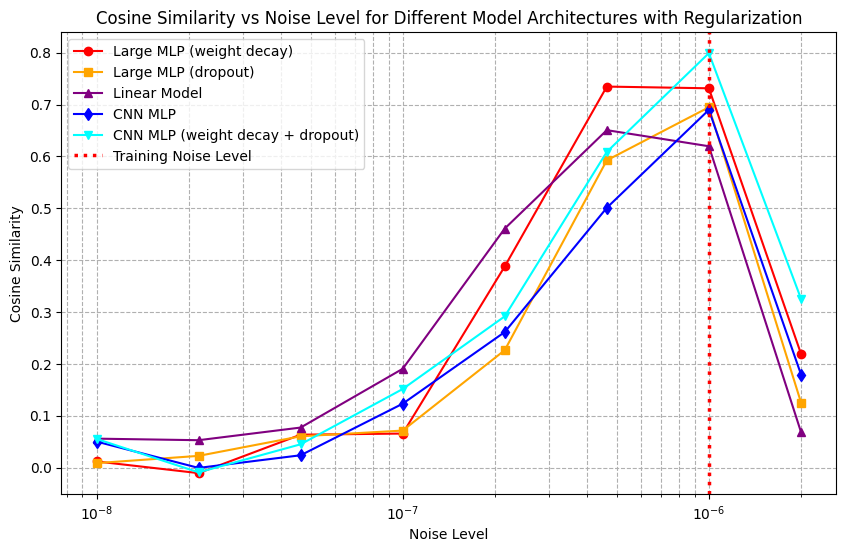

In [205]:
large_mlp_LA_wd_exp1_cos_sim = np.array(large_mlp_LA_wd_exp1['cosine_similarity']['mean'])
large_mlp_LA_drop_exp1_cos_sim = np.array(large_mlp_LA_drop_exp1['cosine_similarity']['mean'])
lm_LA_exp1_cos_sim = np.array(lm_LA_exp1['cosine_similarity']['mean'])
cnnr_LA_exp1_cos_sim = np.array(cnnr_LA_exp1['cosine_similarity']['mean'])
cnnr_LA_wd_drop_exp1_cos_sim = np.array(cnnr_LA_wd_drop_exp1['cosine_similarity']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_levels, large_mlp_LA_wd_exp1_cos_sim, marker='o', label='Large MLP (weight decay)', color='red')
plt.plot(noise_levels, large_mlp_LA_drop_exp1_cos_sim, marker='s', label='Large MLP (dropout)', color='orange')
plt.plot(noise_levels, lm_LA_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_LA_exp1_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, cnnr_LA_wd_drop_exp1_cos_sim, marker='v', label='CNN MLP (weight decay + dropout)', color='cyan')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures with Regularization')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()